# BCA calibration: the pipeline and its theory in action

This notebook shows how BCA's calibration works and what each part does, using the repo's own code and recorded
runs. The first figure is the whole pipeline. The next five each take one theoretical component and run it on real
data:

1. **Pipeline.** How BCA goes from the offline dataset, through host training and calibration, to the four kinds of
   test, with the status of each test.
2. **WBCP threshold.** How weighted Bayesian conformal prediction (Lou & Luo, Algorithm 1; uniform weights = BQ-CP)
   turns a bank of held-out scores into a certified threshold.
3. **Distribution shift.** What importance weights do when the test law differs from the calibration law, and what
   they cost.
4. **Episode dependence.** Why a bank of whole episodes breaks the guarantee and a thinned bank restores it.
5. **Critic alignment.** Why a band calibrated on min(Q1, Q2) does not certify the Q1 that TD3+BC's actor climbs.
6. **Dose.** How the calibrated width becomes a BC multiplier, why it acts as nearly uniform extra BC, and why matching
   the mean dose does not match strength.

**Conventions used throughout.**
- Calibration settings: target miscoverage α = 0.1 at credibility β = 0.95, M = 1,000 posterior draws.
- A calibration bank **fails** when the threshold it certifies misses more than 10% of test rows. A valid rule fails
  in at most 5% of banks (1 − β), the dashed budget line in the figures.
- Colors: **blue** is the method working as intended (WBCP, the Q1 band); **orange** is the case being explained
  (uniform BQ-CP under shift, whole-episode banks, the min(Q1, Q2) band, the oracle dose). Panels marked
  *Illustration* are constructed examples; everything else is computed from recorded data.
- Under each figure, a table lists every number it shows with its source.

**What these figures do not show.** All D4RL evidence comes from frozen critics (one 100k-update critic per host and
dataset, one seed) at logged actions. No WBCP training run exists yet, so nothing here measures return. The
TD3+BC host benchmark is still running, and the step-4 placement study has no outcomes yet.

To rebuild after new runs: `python experiments/wbcp/visualizations_notebook.py`. The figure files are
`experiments/wbcp/viz/fig_<key>.py` and the explanations `experiments/wbcp/viz/text/<key>.md`.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1]  # this notebook lives in experiments/wbcp
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import importlib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from experiments.wbcp.viz import style as S

%matplotlib inline
pd.set_option("display.max_colwidth", None)
print("font:", S.setup())


def draw(key):
    # Run experiments/wbcp/viz/fig_<key>.py, save runs/wbcp_viz/<key>.png, show the figure and its facts.
    module = importlib.import_module(f"experiments.wbcp.viz.fig_{key}")
    fig, facts = module.make()
    path = S.save(fig, key)
    display(fig)
    plt.close(fig)
    print(f"saved {path.relative_to(ROOT)}")
    display(pd.DataFrame(facts, columns=["what", "value", "source"]).style.hide(axis="index"))

font: IBM Plex Sans


## 1. The whole pipeline, from training to testing

### What this shows

BCA leaves the host algorithm (TD3+BC, ReBRAC, CQL or IQL) as it is and changes **one detached term of its loss**. The size of that change comes from a calibrated band on the critic's one-step Bellman residual. The diagram has three bands:
- **Training** is the host's own machinery.
- **Calibration** is what BCA adds.
- **Testing** lists the four studies that check BCA, each with its status.

**1. Episode reservation** (`calibration/reference.py` `reserve_calibration`, `calibration/bank.py` `stratified_bank`). BCA withholds $m=\lceil n/K\rceil$ episodes, each drawn with probability proportional to its length. The bank takes one row from each of $K$ equal segments of every withheld episode. Any surplus over $n$ is then removed at random, which leaves $n$ rows: 248 to 8,192, depending on host and dataset. The host trains only on the episodes that were not withheld. Thinning matters: a bank of whole episodes fails in about 28% of banks on hopper-medium, with no shift at all (DEPENDENCE.md).

**2. Scale fit, every update** (`fit_scale`; ALGORITHMS.md Procedure B). On each training minibatch BCA updates the live scale $\sigma(s,a)=u\cdot\max(\eta_\psi(s,a),10^{-6})$. The network $\eta_\psi$ takes one Adam step on

$$\mathcal L_\text{scale}=\Big(\textstyle\sum_i w_i\,\mathrm{cov}_i-(1-\alpha)\Big)^2+\lambda_w\sum_i w_i\eta_i^2,$$

where $\mathrm{cov}_i$ is a soft indicator that the residual lies inside the band and $w$ are Bayesian-bootstrap masses. The unit $u$ is not trained by this loss. It follows an exponential moving average of the residual spread, $u\leftarrow0.99\,u+0.01\,\mathrm{std}_B(y-q)$; IQL averages its per-batch unit instead. The host's parameters are never touched.

**3. Refresh: freeze the scale, score the bank, run WBCP** (`freeze_reference`, `calibration/wbcp.py`). The first refresh comes after update 10,000, and its result is used from update 10,001. Later refreshes run every 5,000 updates up to 995,000, so a run has 198 refreshes. Each refresh freezes $(\psi_f,u_f)$ and scores the bank with the current critic:

$$\rho_j=\frac{|y_j-\min_k Q_k(s_j,a_j)|}{\sigma_f(s_j,a_j)}.$$

Here $y_j$ is the host's own Bellman target. IQL takes the min over its target heads; the other hosts take it over their online heads. WBCP with uniform weights (exactly BQ-CP) then draws $M=1{,}000$ Dirichlet masses over the $n$ scores plus one test atom at the worst case. For each draw $m$, $\lambda^{(m)}$ is the first sorted score whose cumulative mass reaches $1-\alpha$. The threshold is

$$\lambda_\text{HPD}=\lambda^{(\lceil\beta M\rceil)},\qquad R=\max(\hat\lambda,\lambda_\text{HPD}),\qquad \alpha=0.1,\ \beta=0.95,$$

where $\hat\lambda$ is the empirical $(1-\alpha)$ quantile. Equivalently, $R$ is the smallest score that is $\beta$-credible and is not below $\hat\lambda$. The diagram's box states it this way.

**4. Width and dose** (`calibration/dose.py`, `calibration/advantage.py`). Between refreshes, each training row $(s,a)$, at its logged action, gets

$$U(s,a)=R\,\sigma_f(s,a),\qquad m=1+0.5\,\frac{U}{U+u_f}\in[1,1.5).$$

What the dose touches depends on the host:
- **TD3+BC and ReBRAC:** $m$ multiplies the actor BC term (ReBRAC's critic BC term stays fixed).
- **CQL:** $m$ multiplies each row's conservative gap.
- **IQL:** for rows with $A>0$, the excess of the capped actor weight above 1 is shrunk: $w=1+\frac{A}{A+U}\,(\min(e^{\beta A},100)-1)$.

Everything is detached from the gradient. Before the first refresh there is no dose, and every host keeps its native weighting.

### How to read it

- **Pipeline flow.** Follow the arrows along the top row: dataset → reservation → host training. Then go down into calibration. Scale fit → score the bank → WBCP threshold run right to left. The frozen $R$ and $\sigma$ travel along the bottom lane into width → dose, which feeds back up into one host loss term.
- **Colours and borders.**
  - Ink borders and arrows are the host's own code.
  - Blue borders and arrows are BCA's additions.
  - The dashed blue bracket marks the steps that run only at a refresh. Everything else in the calibration band runs every update.
- **Tags.** Numbered tags (1–4) on the pipeline boxes match the four tests below. Each test checks one thing:
  1. whether the threshold is valid;
  2. whether the dose tracks the true Q error and changes the true value;
  3. where the dose should be applied;
  4. return after full training.
- **Status chips.** Solid blue means **done**, dashed light blue **running**, and dotted grey **next**.
  - **Test 1** is done on TD3+BC's pools (DEPENDENCE.md, Change 12) and in the ReBRAC, CQL and IQL host matrices (IQL finished on 2026-10-02: 55 of 55 runs, `results_iql.ipynb`). TD3+BC's host matrix started after IQL finished and is running.
  - **Test 3**, the step-4 placement study, is in its pilot and has no outcomes yet.
  - **Test 4**, full D4RL training, has not been run and needs approval.

### Takeaway

BCA's intervention is narrow and fully detached: one scalar per row, multiplying one loss term per host. What it calibrates is a normalised one-step Bellman residual on held-out rows of the behaviour data, not the policy's return.

The testing ladder therefore checks the pieces separately:
- **Is the threshold valid?** Test 1 checks it on frozen pools, with and without imposed shift.
- **Does the dose carry useful signal?** Test 2 uses a known MDP with exact $Q$.
  - The dose tracks the true Q1 error, but it stays below 1.5 and varies by only about 0.02 from row to row.
  - Against a constant dose with the same mean, BCA's change in true value differs by a median 6% of its effect (SIGNAL_STUDY.md).
- **Where should the signal be applied?** Test 3, the step-4 placement study, is still running.
- **Does any of it improve return?** Test 4, full D4RL training, has not been run.

### Sources

- Code:
  - `calibration/reference.py` (`reserve_calibration`, `freeze_reference`, `initial_reference`)
  - `calibration/bank.py`, `calibration/wbcp.py`, `calibration/dose.py`, `calibration/advantage.py`, `calibration/network.py`
  - `algorithms/{td3_bc,rebrac,cql}_bca.py` (`fit_scale`, `refresh`)
  - `calibration/iql_reference.py`, `calibration/iql_scale.py`
  - `runtime/{td3_bc,rebrac,cql,iql_pair}.py` (refresh call sites)
- Configs:
  - `configs/experiment.yaml`: 1M updates, warmup 10k, refresh every 5k to 995k.
  - `configs/{td3_bc,rebrac,cql,iql}.yaml`: α, β, M, blend 0.5, bank sizes.
- Docs: `ALGORITHMS.md` (Procedures A–D, Algorithms 1–4, Schedules) and `INTEGRATION.md`.
- Tests and their status:
  - Test 1: `experiments/wbcp/d4rl_benchmark.py`, `experiments/wbcp/host_matrix.py`, `experiments/wbcp/README.md`, `experiments/wbcp/DEPENDENCE.md`, and the file counts in `runs/wbcp_hosts/<host>/`.
  - Test 2: `experiments/signal/lq_harness.py`, `experiments/signal/SIGNAL_STUDY.md`.
  - Test 3: `experiments/signal/run_step4.py`, `experiments/signal/STEP4_DESIGN.md`.
  - Test 4: `train.py`.
- Figure module: `experiments/wbcp/viz/fig_pipeline.py`.

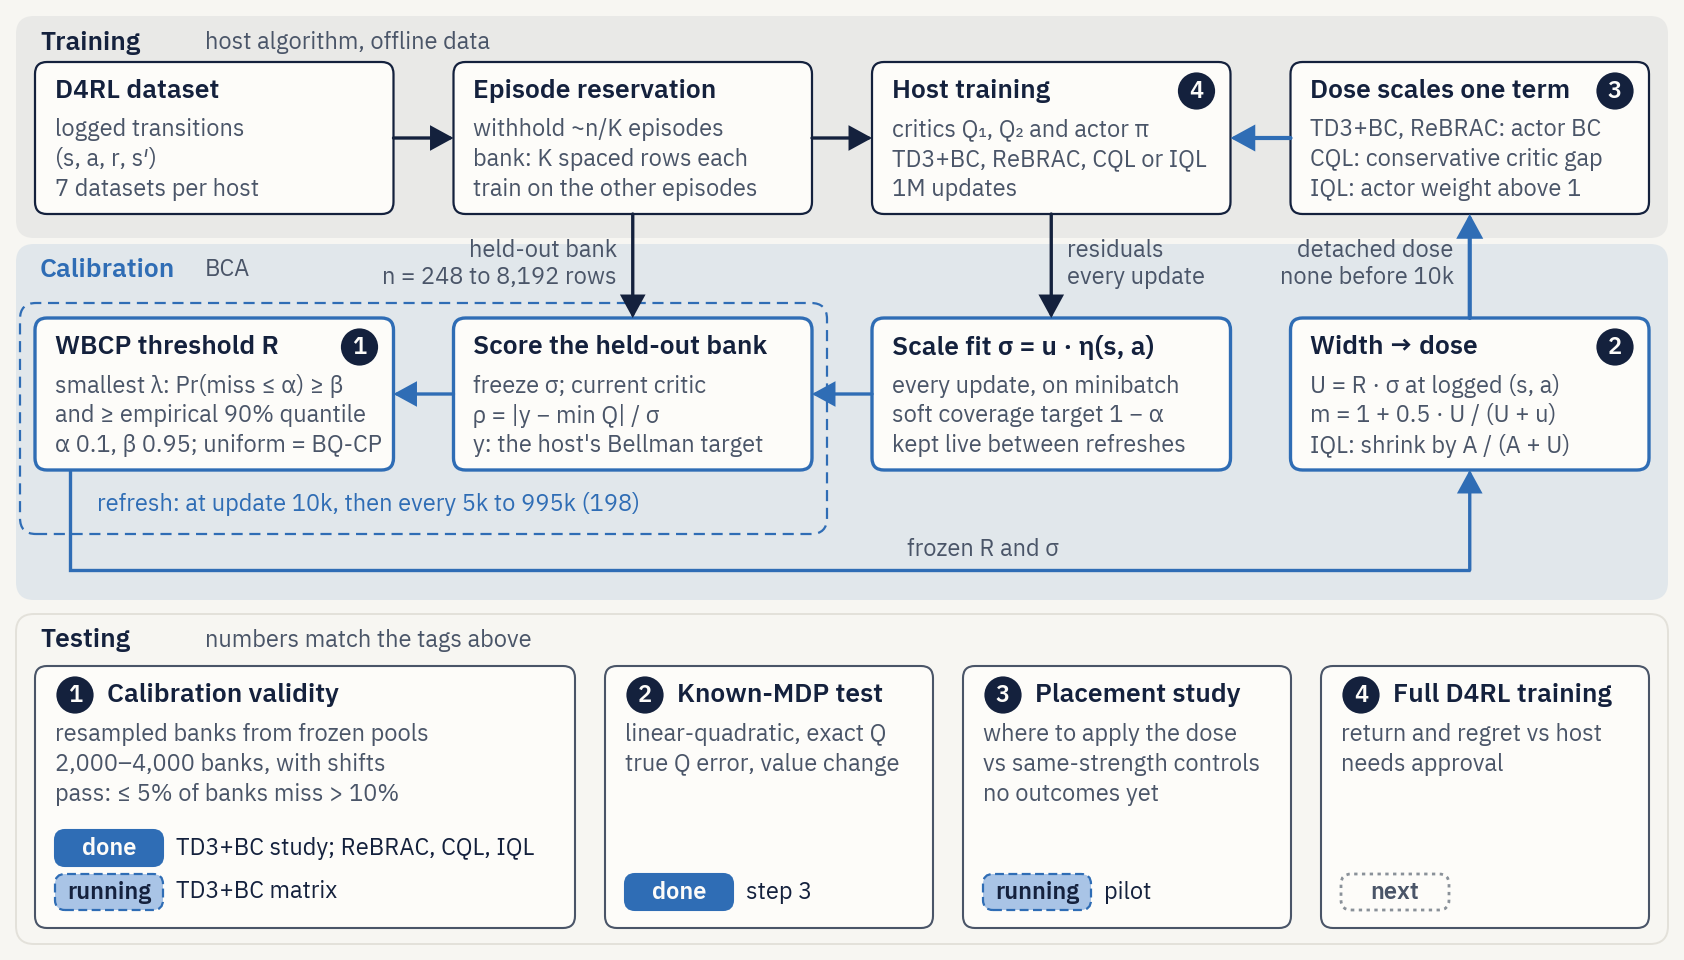

saved runs\wbcp_viz\pipeline.png


what,value,source
"box: D4RL dataset (HDF5 checked by SHA-256, host transition conversion)",7 datasets per host,"runtime/{td3_bc,rebrac,cql,iql}.py preparation; configs/.yaml datasets; experiments/wbcp/host_matrix.py:39 DATASETS"
"box: Episode reservation (withhold ceil(n/K) length-weighted episodes, K spaced rows each, train on the complement)",reserve_calibration,calibration/reference.py:49-121; calibration/bank.py:45 stratified_bank; algorithms/_bca.py reserve_pool; calibration/iql_reference.py:265 prepare_dataset
held-out bank size n across hosts and datasets,"248 to 8,192 rows","configs/{td3_bc,rebrac,cql,iql}.yaml reservation.size; ALGORITHMS.md:319"
"box: Host training (twin critics + actor; TD3+BC, ReBRAC, CQL, IQL)",1M updates,"configs/experiment.yaml:2 num_updates 1000000; runtime/{td3_bc,rebrac,cql,iql_pair}.py; algorithms/{td3_bc,rebrac,cql,iql}.py"
"box: Dose scales one host loss term: TD3+BC actor BC (bc_multiplier), ReBRAC actor BC (actor_bc_multiplier; critic BC fixed), CQL conservative gap (conservative_multiplier), IQL actor weight excess above 1",one term per host,"ALGORITHMS.md:43-48 and 321-363; INTEGRATION.md:15-20; algorithms/td3_bc.py:100; algorithms/rebrac.py:172; algorithms/cql.py:162,300; calibration/iql_state.py actor_update"
"box: Scale fit sigma(s,a) = u * max(eta_psi(s,a), 1e-6), every update on the training minibatch: psi by Adam on (soft coverage - (1 - alpha))^2 + width penalty; unit u by EMA u <- 0.99 u + 0.01 std(y - q) (IQL: of its per-batch unit)",every update,"algorithms/td3_bc_bca.py:159, rebrac_bca.py:283, cql_bca.py:176 fit_scale; calibration/iql_scale.py; calibration/network.py:34 soft_coverage; ALGORITHMS.md:232-265"
"box: Score the held-out bank, rho = |y - min_k Q_k| / sigma_f with the current critic (IQL: min over target heads)",freeze_reference,"calibration/reference.py:152-175; algorithms/td3_bc_bca.py:234 refresh, rebrac_bca.py:340, cql_bca.py:227; calibration/iql_reference.py:184; INTEGRATION.md:895-"
"box: WBCP threshold R = max(lambda_hat, lambda_HPD): the smallest score that is beta-credible (lambda_HPD = ceil(beta M)-th sorted per-draw crossing, Dirichlet masses plus a worst-case test atom) and not below the empirical (1 - alpha) = 90% quantile lambda_hat; uniform weights = BQ-CP",calibrate,"calibration/wbcp.py:43-54 crossings, 89-102 lambda_hat, 115-117 lambda_hpd and max; calibration/reference.py:175-179; ALGORITHMS.md Procedure C steps 4-5"
alpha (target miscoverage),0.1,calibration/reference.py:18; configs/.yaml bca.alpha
beta (credibility),0.95,calibration/reference.py:19; configs/.yaml bca.credibility


In [2]:
draw("pipeline")

## 2. WBCP: from a calibration bank to a threshold

### What this shows

At each refresh, BCA calibrates one number: a threshold $\lambda$ on the normalized critic residual score

$$s = \frac{|y - q|}{\sigma},\qquad y = \text{host Bellman target},\quad q = \min(Q_1, Q_2),\quad \sigma = \max(\eta, 10^{-6})\,u,$$

where $\eta$ is the learned scale network and $u$ the frozen residual unit (`calibration/reference.py:148-175`). The deployed threshold times $\sigma$ is the width that the dose reads (`calibration/dose.py:65-76`).

WBCP (Lou & Luo, arXiv:2604.06464v3, Algorithm 1) turns a bank of $n$ held-out scores into that threshold. BCA runs it with uniform weights ($w_i = 1$, $\bar w = 1$; `calibration/reference.py:176`). That is exactly BQ-CP (Snell & Griffiths, 2025).

The figure runs `calibration/wbcp.calibrate` on real banks. The scores come from the frozen TD3+BC hopper-medium-v2 pool: a critic trained for 100k updates, then frozen, scores every row of the held-out half of the dataset. Each bank is drawn with BCA's own reservation sampler, which takes $K = 6$ rows from each reserved episode. The settings are $\alpha = 0.1$, $\beta = 0.95$ and $M = 1000$ posterior draws, as in `configs/td3_bc.yaml`.

**Step 1: point estimate (Eq. 1).** $\hat\lambda$ is the smallest score whose weighted empirical miscoverage is at most $\alpha$:
$$\hat\lambda = \min\Big\{\lambda:\ \frac{\sum_i w_i\,\mathbf 1\{s_i > \lambda\}}{\sum_i w_i} \le \alpha\Big\}.$$

**Step 2: posterior over the calibration law (Eqs. 3, 6).** Each draw $m$ puts random masses on the $n$ scores. It also puts one mass on a *test atom*. The test atom stands for the unseen test point and is placed at the worst-case loss, so it is never covered:
$$E_1,\dots,E_{n+1}\overset{iid}{\sim}\mathrm{Exp}(1),\qquad V_i = \frac{w_i E_i}{\sum_j w_j E_j + \bar w E_{n+1}},\qquad V_{n+1} = \frac{\bar w E_{n+1}}{\sum_j w_j E_j + \bar w E_{n+1}}.$$
With uniform weights, $(V_1,\dots,V_{n+1})\sim\mathrm{Dirichlet}(1,\dots,1)$. The posterior miscoverage at $\lambda$ is $L^+(\lambda) = \sum_i V_i\,\mathbf 1\{s_i>\lambda\} + V_{n+1}$.

**Step 3: each draw's crossing.** $L^+(\lambda)\le\alpha$ exactly when the posterior mass of the scores at or below $\lambda$ reaches $1-\alpha$:
$$\lambda^{(m)} = \min\Big\{s_{(j)}:\ \sum_{i\le j} V^{(m)}_{(i)} \ge 1-\alpha\Big\}.$$
The crossing is $+\infty$ if the test atom alone exceeds $\alpha$. That did not happen in any draw shown here.

**Step 4: credible threshold (Eq. 7), then deploy.**
$$\lambda_{\rm hpd} = \min\{\lambda:\ \Pr(L^+(\lambda)\le\alpha\mid\text{bank})\ge\beta\} = \text{the } \lceil\beta M\rceil\text{-th smallest } \lambda^{(m)},\qquad \lambda_{\rm dep} = \max(\hat\lambda,\ \lambda_{\rm hpd}).$$

### How to read it

**Panel a: posterior CDFs for one bank of $n = 256$ scores from 43 episodes.**
- The orange step is the empirical CDF. It crosses the $1-\alpha$ line at $\hat\lambda$ (the diamond).
- The light-blue steps are the first 30 of `calibrate()`'s 1,000 Bayesian-bootstrap CDFs. The module regenerates them from the same random stream and checks that they reproduce `calibrate()`'s crossings exactly.
- Each blue dot on the dashed line is one draw's crossing $\lambda^{(m)}$.
- No blue curve ever reaches 1, because each draw keeps the mass $V_{n+1}$ on the test atom at $+\infty$.
- The x-axis is cut at 2.05. Six of the 256 scores lie beyond the cut (the largest is 5.31), so the gap to 1 at the right edge also holds those scores, not only the test atom.
- The y-axis starts at 0.6 to zoom in on the crossings.

**Panel b: all 1,000 crossings of that bank, which together are the threshold posterior.** Every crossing is one of the bank's own scores, so the posterior is drawn as stems: the number of draws that cross at each score.
- $\hat\lambda = 1.008$ (orange dashed line) sits in the bulk of the posterior.
- $\lambda_{\rm hpd} = 1.289$ (blue line) is the smallest score with at least 95% of draws at or below it. 31 draws (grey) cross above it. It exceeds $\hat\lambda$, so it is the deployed threshold.
- The dotted line is the pool's true 90% point, $\lambda^* = 1.064$, computed from all 500,285 pool scores.
- "misses" is each threshold's true miscoverage on the pool rows outside the bank. $\hat\lambda$ misses 11.3%, more than $\alpha$, so used alone it would make this a failed bank. The deployed threshold misses 6.2%.

**Panel c: one bank each of $n$ = 64, 256 and 1,024.** 1,024 is the configured TD3+BC hopper size.
- The thin line spans all draws.
- The bar spans the middle 90%, from the 50th to the 950th smallest crossing, so its top is $\lambda_{\rm hpd}$.
- The diamond is $\hat\lambda$. The blue dot is the deployed threshold, labelled with its true miscoverage.
- The posterior sd falls from 0.408 to 0.120 to 0.054.
- The deployed threshold moves down toward $\lambda^*$, and its miscoverage rises toward $\alpha$ without passing it: 1.1%, 6.2%, 8.3%.

### Takeaway

- $\hat\lambda$ alone is the bank's empirical 90% point. It scatters around $\lambda^*$, and it misses more than $\alpha$ whenever it lands below $\lambda^*$. In two of the three banks shown, it lands below: it misses 11.3% at $n=256$ and 10.5% at $n=1{,}024$.
- WBCP deploys the $\beta$-credible crossing rather than the centre of the posterior. This adds the margin that the bank's own uncertainty calls for. The margin is large for a small bank (the $n=64$ threshold misses only 1.1%) and shrinks as the bank grows.
- The guarantee is about frequency across banks: at most $1-\beta = 5\%$ of banks should fail. One bank per $n$, as shown here, illustrates the mechanism but does not measure that rate.
- On this pool, the benchmark measured 5.1% [4.4, 5.8] failed banks (204 of 4,000) for uniform BCA with BCA's sampler at $K=5$, $n=1{,}103$ (DEPENDENCE.md, Change 9). Two qualifications apply:
  - That run predates the remainder trim, so its banks held 1,105 rows. `dependence_evidence.json` notes that a rerun is needed to confirm it.
  - The benchmark scores $\lambda_{\rm hpd}$ (`d4rl_benchmark.py:453`), not the deployed $\max(\hat\lambda, \lambda_{\rm hpd})$. The deployed threshold is never lower, so its failure rate can only be equal or smaller.
- The configured design ($K=6$, $n=1{,}024$) has no TD3+BC entry in `calibration/dependence_evidence.json` yet.

### Sources

- `calibration/wbcp.py`:
  - `calibrate()`: Eq. 1 at lines 89-102, posterior draws at 104-111, Eq. 7 at 115, deployed max at 117.
  - `crossings()` at lines 43-54, including the test atom in the total at line 52.
- `calibration/reference.py:148-179`: the score and BCA's call with uniform weights.
- `calibration/dose.py:65-76`: the width is the deployed threshold times the scale.
- `calibration/bank.py`: `stratified_bank`.
- `experiments/wbcp/d4rl_benchmark.py`: `load_pool`, `episode_groups`, `draw_calibration` (spacing `reservation`), `stream` (seed 2026093001, trial 0), `ExactRisk.lambda_star`, and the BQ-CP arm at line 453.
- `configs/td3_bc.yaml`: `bca.alpha`, `credibility`, `draws`; `datasets.hopper.reservation` (size 1024, `rows_per_episode` 6).
- `runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000/frozen.npz` and `frozen.json` (`score_definition`, `rows.heldout` = 500,285, `population_episodes` = 1,094).
- `experiments/wbcp/DEPENDENCE.md`: $\lambda^* = 1.064$ and the Change 9 table.
- `calibration/dependence_evidence.json`: the td3_bc hopper entry at K = 5, n = 1,103 (204/4000, `bank_trim` null).
- Figure module: `experiments/wbcp/viz/fig_wbcp_threshold.py`.

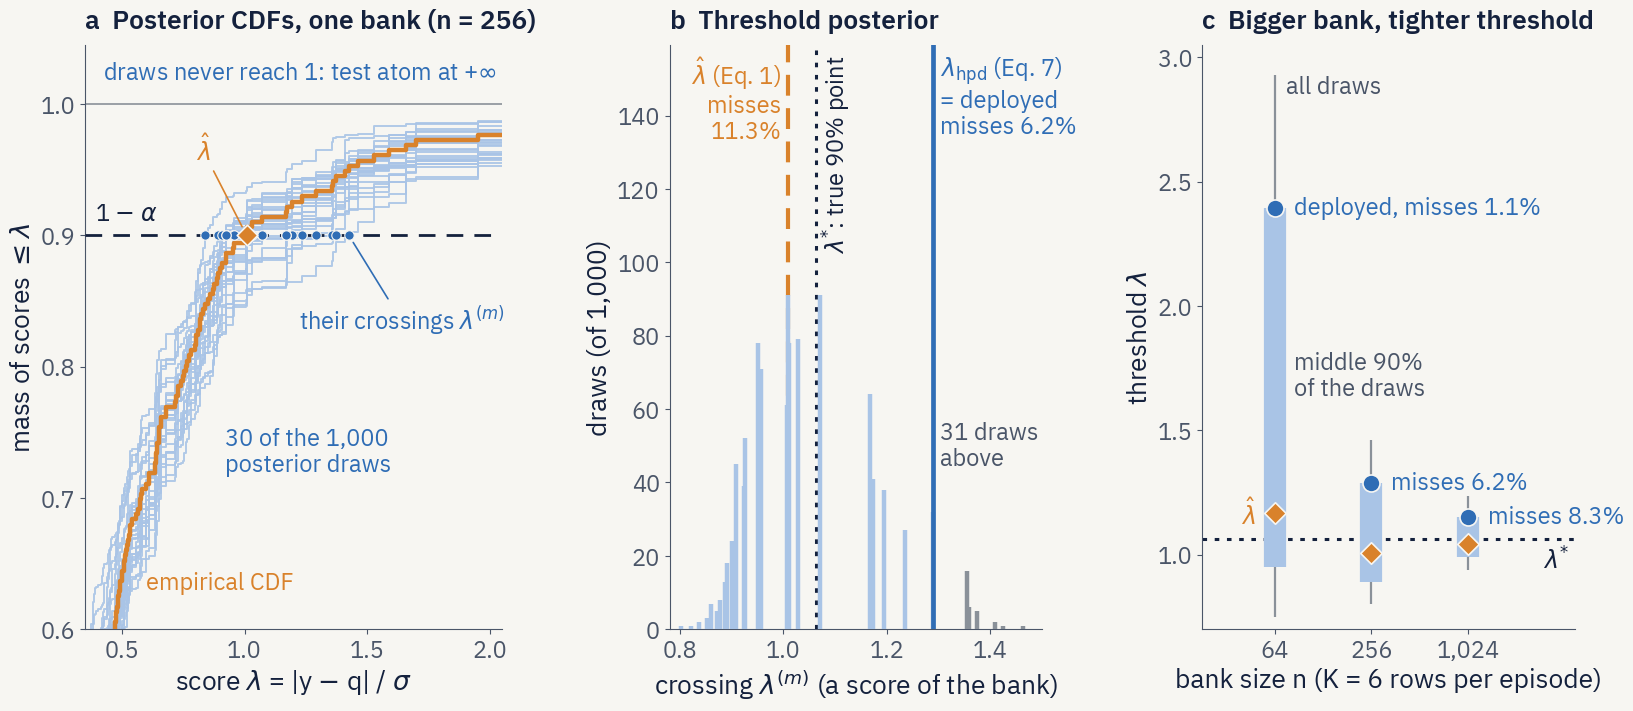

saved runs\wbcp_viz\wbcp_threshold.png


what,value,source
"Score pool: TD3+BC hopper-medium-v2, 100k updates, held-out rows / episodes","500,285 rows, 1,094 episodes",runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000/frozen.npz (heldout population)
Bank sampler and rows per episode K,"stratified_bank (reservation), K = 6",calibration/bank.py stratified_bank; configs/td3_bc.yaml datasets.hopper.reservation
Random streams of the banks and posteriors,"d4rl_benchmark.stream(seed 2026093001, 'cal'|'bq', n, trial 0)",experiments/wbcp/d4rl_benchmark.py stream(); seed = benchmark_seed in calibration/dependence_evidence.json
"alpha (1 - alpha line in panel a), beta, posterior draws M","alpha = 0.1, 1 - alpha = 0.9, beta = 0.95, M = 1,000",configs/td3_bc.yaml bca.alpha / credibility / draws
Posterior CDF draws shown in panel a,"first 30 of 1,000",computed: calibrate()'s exponentials regenerated from the same stream; crossings checked equal to Calibration.crossings
Panel a/b bank: size and episodes,"n = 256, 43 episodes","computed with draw_calibration(..., per_episode=6, spacing='reservation')"
Pool's true 90% point lambda* (smallest score with miscoverage <= 0.1 over the pool),1.064,computed: d4rl_benchmark.ExactRisk(...).lambda_star(0.1); DEPENDENCE.md reports 1.064 for this pool
Draws whose crossing lies above lambda_hpd (n = 256),31,computed from Calibration.crossings
"n = 64 bank: lambda_hat (Eq. 1), lambda_hpd (Eq. 7), deployed max","1.167, 2.396, 2.396 (11 episodes)","computed: calibration/wbcp.py calibrate() (uniform weights, as calibration/reference.py)"
n = 64 bank: true miscoverage of the deployed threshold on the rest of the pool,1.1%,computed: share of pool rows outside the bank scoring above it


In [3]:
draw("wbcp_threshold")

## 3. Distribution shift: uniform BQ-CP vs importance-weighted WBCP

### What this shows

Under **covariate shift**, test rows come from a different law than the calibration bank, but the score of a given state-action keeps its law. Let $w(x) = dP_{\text{test}}/dP_{\text{cal}}(x)$. Then the true test miscoverage of a threshold $\lambda$ is a *weighted* tail mass of the calibration law:

$$L_{\text{test}}(\lambda) = \Pr_{\text{test}}(S > \lambda) = \frac{\mathbb{E}_{\text{cal}}\big[w(X)\,\mathbf 1\{S>\lambda\}\big]}{\mathbb{E}_{\text{cal}}[w(X)]}.$$

The benchmark applies this shift to a real frozen score pool: hopper-medium-v2, 500,285 held-out rows. The scores come from a TD3+BC model trained for 100k updates with BCA's scale fit: $s = |y - q|/\sigma$, where $q = \min(Q_1, Q_2)$. Row $i$ gets test probability $\propto a_i = e^{\gamma z_i}$. Here $z$ is the standardized log distance to the 10th nearest neighbour in standardized $(s,a)$ space, measured against a seeded 10,000-row reference subset of the pool. This is the **density** tilt: rows in sparse regions gain mass. The exact ratio and test mass are

$$w^*_i = \frac{a_i}{\operatorname{mean}(a)}, \qquad \bar w = \mathbb{E}_{\text{test}}[w^*] = \frac{\operatorname{mean}(a^2)}{\operatorname{mean}(a)^2}.$$

**WBCP** (Lou & Luo, Algorithm 1) draws Bayesian-bootstrap variables $E_1,\dots,E_{n+1}\sim\text{Exp}(1)$. Score $s_i$ gets mass $w_iE_i$. A test atom of mass $\bar w E_{n+1}$ sits at the worst-case loss:

$$L^+(\lambda) = \frac{\sum_{i:\,s_i>\lambda} w_i E_i + \bar w E_{n+1}}{\sum_j w_j E_j + \bar w E_{n+1}}, \qquad \lambda_{\text{hpd}} = \min\{\lambda : \Pr(L^+(\lambda)\le\alpha) \ge \beta\}.$$

Here $\lambda$ ranges over the bank's scores. WBCP deploys $\max(\hat\lambda_w, \lambda_{\text{hpd}})$, where $\hat\lambda_w$ is the weighted empirical $(1-\alpha)$ quantile. With $w_i = \bar w = 1$ this is exactly **BQ-CP**, the uniform calibration BCA runs today (`calibration/reference.py:176-179` calls `calibrate()` without weights and deploys the clamped threshold). The benchmark's BQ-CP arm records $\lambda_{\text{hpd}}$. For the bank in panel b the clamp does not bind, so the two agree. Uniform BQ-CP certifies the *calibration* law, so it can under-cover the test law.

Weighting costs information. Heuristically, the posterior behaves like a sample of Kish size

$$n_{\text{eff}} = \frac{(\sum_i w_i)^2}{\sum_i w_i^2} \le n,$$

so it is wider and its threshold is higher. With very uneven weights, the test atom's share alone can exceed $\alpha$ in more than $1-\beta$ of the draws. WBCP then abstains ($\lambda=\infty$).

Settings: $\alpha = 0.1$ and $\beta = 0.95$. A bank **fails** when its certified threshold misses more than 10% of test rows. A valid rule fails in at most 5% of banks.

### How to read it

- **a: The tail grows.**
  - x is a threshold λ on the normalized score |y − q|/σ.
  - y is the share of rows whose score exceeds λ, which is λ's true miscoverage.
  - Orange dashed: the calibration law, where every pool row is equally likely.
  - Blue: the tilted test law at γ = 1. It uses the same rows, reweighted by $w^*$. The largest weight is 33× the mean.
  - The orange dot is the threshold that is exact for the calibration law (λ = 1.06). The blue dot above it shows that this threshold misses 13.0% of test rows.
  - The black dot is the test law's own 10% point, λ* = 1.20.
- **b: One bank, two threshold posteriors.**
  - This is one real 1,103-row bank, drawn with the benchmark's own random streams. It is the first bank in benchmark order with the majority outcome; bank 0, where both rules fail, was skipped.
  - Each curve is a threshold posterior drawn as a CDF: at each λ, the posterior probability $\Pr(L^+(\lambda)\le\alpha)$ over 1,000 bootstrap draws. Both curves are step functions because each draw crosses at one of the bank's scores.
  - Each method deploys where its curve reaches β = 0.95 (the dots). The vertical line is λ*; any threshold to its left fails.
  - Uniform BQ-CP is steep: all 1,103 rows count fully, and the posterior SD is 0.038. It sits on the calibration law, certifies 1.07 and misses 12.8%.
  - WBCP is flatter (n_eff = 344, SD 0.119) and shifted right. It certifies 1.33 and misses 7.8%.
- **c: The benchmark.**
  - For each shift strength γ: the share of 2,000 iid banks (n = 1,103) whose certified threshold misses more than 10% of tilted-test rows.
  - Error bars are exact 95% intervals. The y axis is log scale.
  - Orange dashed: uniform BQ-CP.
  - Blue solid, filled circles: WBCP with exact weights.
  - Blue dotted, open diamonds: WBCP with weights from a logistic discriminator. The two WBCP series are offset slightly sideways so that neither hides the other.
  - The dotted horizontal line is the 5% budget (1 − β).
  - The second row of x labels is the mean Kish n_eff of a bank's exact weights.

### Takeaway

- **No shift.** All three rules fail about 5% of banks (4.85-5.0%), as they should.
- **Uniform BQ-CP is shift-blind.** It fails 42.6% of banks at γ = 0.5, 89.5% at γ = 1 and 100% at γ = 2.
- **WBCP nearly restores the guarantee.**
  - At γ = 0.5 it fails 4.3% of banks with exact weights and 4.2% with estimated weights.
  - At γ = 1 it fails 7.55% and 7.35%. This excess is finite-sample (DEPENDENCE.md Change 11). In a 4,000-bank sweep it went 7.6% → 6.3% → 6.7% → 6.0% [5.3, 6.8] as the bank grew from 1,103 to 8,824 rows: the excess shrinks but is still above 5% at 8×. Failing banks exceed α by 0.76 points on average.
  - The paper's frequentist slack η_n (Theorem 4) is 1.19 here, far above α, so the paper does not promise a 5% failure rate at this size. Under weighting, credibility is not frequentist confidence. DEPENDENCE.md reports that the paper's own §4.2 experiment gives 7.5-7.9%.
  - At γ = 2 it fails 2.35% / 2.6%, partly because it abstains in 6.3% / 12.1% of banks, and abstentions count as passes.
- **The price is effective sample size.**
  - n_eff falls from 1,103 to 857, 391 and 47 as γ grows.
  - At γ = 1 the mean certified threshold rises from 1.14 (uniform) to 1.40 (WBCP, exact weights), above λ* = 1.20. WBCP is conservative on average, yet 7.55% of banks still fail.
- **Estimated weights** track the exact ones within 0.3 points. Here the discriminator is fitted on the tilt feature itself, so the weight model is correct by construction.

### Sources

- `experiments/wbcp/viz/fig_shift_weighting.py`: this figure. Panels a-b are recomputed from the pool, and the recomputed tilt is checked against main.json.
- `calibration/wbcp.py`: `calibrate()` implements Algorithm 1: crossings at lines 43-54, λ_hpd at 115, n_eff at 116, the deployed max(λ̂, λ_hpd) at 117.
- `calibration/reference.py:176-179`: BCA's uniform calibration.
- `experiments/wbcp/d4rl_benchmark.py`: `load_pool`, `tilt_feature` (193), `standardize`, `make_tilt`, `ExactRisk`, `common_scale` (320), `draw_calibration`, `stream`, `run_trial` (439-475).
- `runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000/frozen.npz` and `frozen.json`: the score pool and its score definition.
- `runs/wbcp_bench/main.json`: panel c and the tilt checks. In results.ipynb this is section 5, "Distribution shift" (the "Independent rows" column); in DEPENDENCE.md it is the iid column of Change 5.
- `runs/wbcp_dependence/hopper-u100000-weighting/a_density1.json` and `certificate_slack.json`: DEPENDENCE.md Change 11 (results.ipynb section 8).
- `experiments/wbcp/DEPENDENCE.md`: Changes 5, 8, 10 and 11.

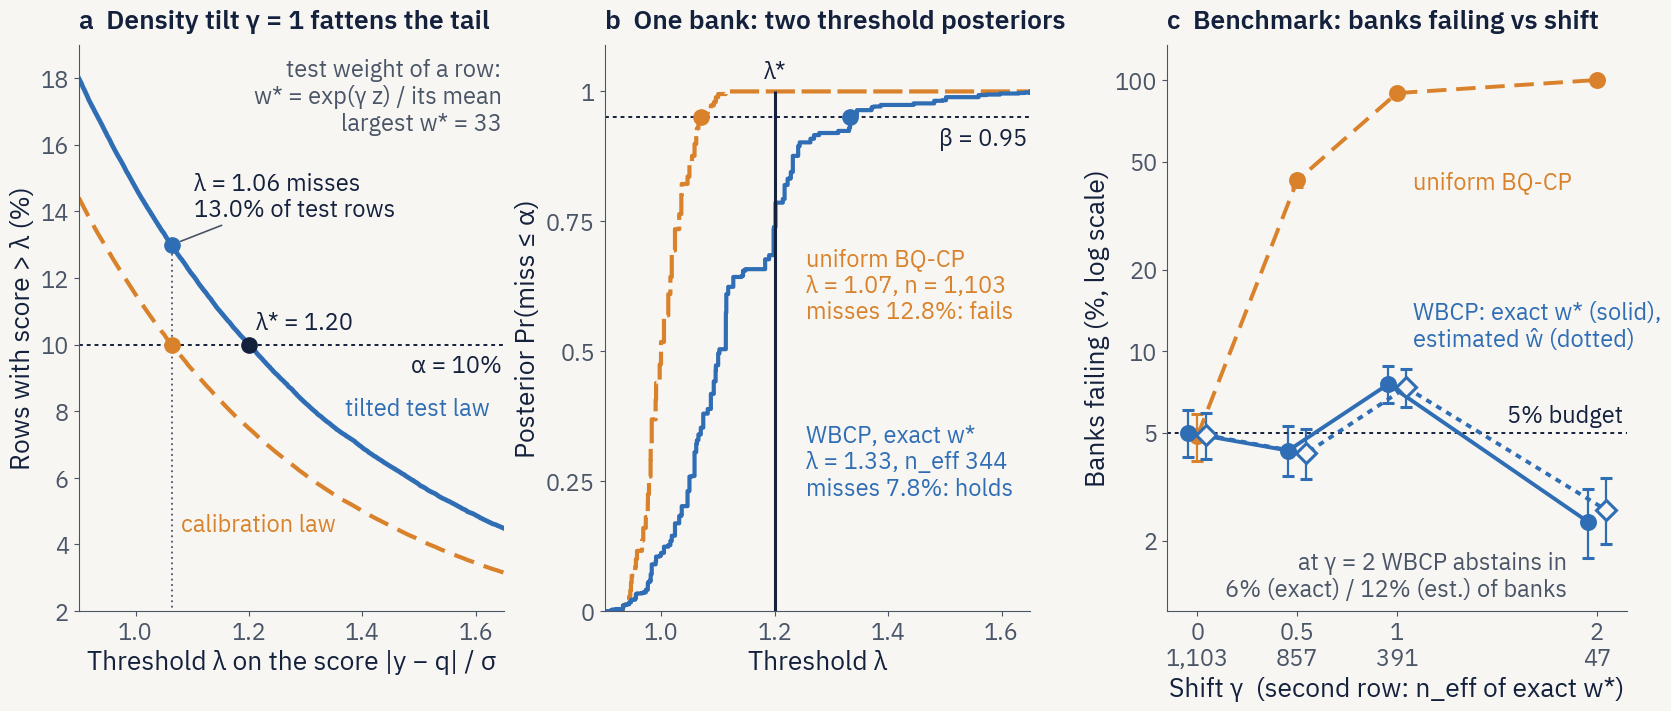

saved runs\wbcp_viz\shift_weighting.png


what,value,source
Pool rows (hopper-medium-v2 held-out half),"500,285",runs/wbcp_bench/main.json population.rows
Shift shown in panels a-b,"density tilt, gamma = 1",runs/wbcp_bench/main.json settings; DEPENDENCE.md Terms
Target miscoverage alpha,10%,runs/wbcp_bench/main.json settings.alpha
Threshold exact for the calibration law (uniform lambda*),1.0636,runs/wbcp_bench/main.json lambda_star_uniform.normalized; recomputed in fig_shift_weighting.py from runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000 with d4rl_benchmark.py tilt_feature/make_tilt/ExactRisk; matches runs/wbcp_bench/main.json
Test-law miscoverage of that threshold,12.99%,recomputed in fig_shift_weighting.py from runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000 with d4rl_benchmark.py tilt_feature/make_tilt/ExactRisk; matches runs/wbcp_bench/main.json
Test-law lambda* (density gamma 1),1.2001,runs/wbcp_bench/main.json block lambda_star
Largest exact weight w* / mean weight,33.2,runs/wbcp_bench/main.json tilts.density.gammas['1.0'].max_oracle_w; DEPENDENCE.md Change 11 table (33)
Tilted pool n_eff (share of rows),"174,638 (34.9%)",runs/wbcp_bench/main.json block tilt_n_eff
Bank shown (benchmark order),"bank 1, n = 1,103 iid rows","computed in fig_shift_weighting.py: benchmark bank 1 (d4rl_benchmark.py run_trial streams, seed 2026093001), calibration/wbcp.py calibrate(alpha=0.1, beta=0.95, draws=1000); miss = ExactRisk under the tilted law over the whole pool"
Uniform BQ-CP threshold (lambda_hpd),1.0697,"computed in fig_shift_weighting.py: benchmark bank 1 (d4rl_benchmark.py run_trial streams, seed 2026093001), calibration/wbcp.py calibrate(alpha=0.1, beta=0.95, draws=1000); miss = ExactRisk under the tilted law over the whole pool"


In [4]:
draw("shift_weighting")

## 4. Episode dependence: why the calibration bank is thinned

### What this shows

BCA calibrates a bank of critic-residual scores $s_1,\dots,s_n$. For the TD3+BC host each score is $s = |y - \min(Q_1,Q_2)(s,a)|/\sigma(s,a)$, where $y$ is TD3+BC's own target and $\sigma$ is BCA's learned scale. The threshold comes from WBCP (`calibration/wbcp.py`). With uniform weights, WBCP is BQ-CP.

The posterior is a Bayesian bootstrap. Each draw $m$ takes $E_1,\dots,E_{n+1} \sim \mathrm{Exp}(1)$ independently. Row $i$ gets the mass $E_i / \big(\sum_{j\le n} E_j + E_{n+1}\big)$. The extra atom $E_{n+1}$ stands for the unseen test point, placed at the worst-case loss. Each draw gives a crossing $\lambda^{(m)}$, the smallest score at which the posterior mass of misses is at most $\alpha$. The deployed threshold is

$$\lambda = \max\big(\hat\lambda,\ \lambda_{\text{hpd}}\big), \qquad \Pr_{\text{post}}\big(L^+(\lambda_{\text{hpd}}) \le \alpha\big) \ge \beta, \qquad \alpha = 0.1,\ \beta = 0.95,$$

where $\hat\lambda$ is the empirical $(1-\alpha)$ quantile and $\lambda_{\text{hpd}}$ is the $\beta$-quantile of the crossings (`wbcp.py:43-117`). A bank **fails** when more than 10% of test rows miss its threshold. A valid rule fails in at most 5% of banks.

The bootstrap treats rows as **exchangeable, independent units**. Rows from one episode are not independent. Let $I = \mathbf{1}\{s > \lambda^*\}$ mark a miss, where $\lambda^*$ is the true 90% quantile. Two rows of the same episode have correlated misses, with intra-class correlation $\rho$ (one-way ANOVA, `experiments/wbcp/dependence.py:42-52`). With $m$ rows per episode, clustering inflates the variance of the bank's miss rate by the **design effect**

$$D \approx 1 + (m-1)\rho, \qquad \operatorname{Var}(\hat p) \approx D\,\frac{p(1-p)}{n}, \qquad n_{\text{eff}} = \frac{n}{D}.$$

The posterior assumes $D = 1$, so its safety margin is $\sqrt{D}$ times too narrow. In a normal approximation (`dependence.py:102-103`) the failure rate becomes

$$\Pr(\text{fail}) \approx 1 - \Phi\!\left(\frac{z_\beta}{\sqrt{D}}\right), \qquad z_{0.95} = 1.645,$$

rather than 5%.

A small $\rho$ is enough to matter because episodes are long. On hopper-medium, a whole-episode bank has a Monte Carlo $D = 6.6$. Its mean of 1,362 rows carries about as much information as 206 independent rows, and 27.8% of such banks fail.

Which $\rho$ goes into the formula depends on how episodes are picked (DEPENDENCE.md Change 2):
- The ANOVA $\rho = 0.016$ shown in panel b is the right input for banks that pick episodes in proportion to their length.
- For whole episodes picked uniformly, the right input is the pair-weighted 0.0115. That gives $D \approx 6.5$, matching the Monte Carlo value.

A bigger bank of whole episodes does not help either. It still fails 26–28% with mean banks of up to 11,739 rows (Change 3), because $D$ depends on the number of rows per episode, not on the number of episodes.

**BCA's fix is a thinned bank** (`calibration/bank.py:45-102`, `stratified_bank`):
- Withhold $m = \lceil n/K\rceil$ distinct episodes. Each episode's inclusion probability is exactly proportional to its length (systematic sampling).
- Cut each episode into $K$ equal segments and take one row from each. Any surplus over $n$ is removed at random.

This gives $D \approx 1 + (K-1)\rho$. Spacing the rows apart lowers $D$ further, because the correlation decays with lag. On hopper it is 0.19 at lag 1, 0.022 at lag 50 and about 0 at lag 200.

The cost is training data, since every row of a withheld episode leaves training. On hopper, K = 5 at n = 1,103 withholds about 10–11% of the data.

### How to read it

- **a**: one bank of each kind, drawn with fixed seed 911 on the real lengths of the 1,094 held-out hopper-medium episodes in the benchmark pool.
  - Orange bars: a whole-episode bank, using the old rule (now kept only for population splits) at `calibration/reference.py:83-86`. Every row of 3 episodes is a calibration row.
  - Blue dots: `stratified_bank` with K = 5 and n = 1,103. It picks 221 episodes, and 6 are drawn here.
    - The whole grey bar leaves training. Only the dots are calibrated.
    - The top episode has 4 dots because 2 surplus rows were dropped across the bank.
  - The large numbers are benchmark failure rates over 4,000 banks each, against 5% allowed.
    - 27.8%: whole episodes.
    - 5.1%: BCA's own sampler. That run predates the surplus trim, so its banks held 1,105 rows.
- **b**: the measured $\rho$ of the miss indicator on the five datasets whose TD3+BC critic was stable. It ranges from 0.016 on hopper to 0.120 on walker2d-medium-replay.
- **c**: every no-shift benchmark run on those five pools (uniform-weight arm, normalized score), placed at its Monte Carlo design effect $D$. Each point is 4,000 banks.
  - Orange: whole episodes.
  - Blue: K = 2–50 stratified (spaced) rows per episode.
  - Grey ring: independent rows, where $D = 1$.
  - The curve is the normal approximation above. The dashed line is the 5% budget.

### Takeaway

On all five datasets, whole-episode banks fail 27–48% of the time. They sit roughly where the design-effect theory puts them, within about 6 points; with only 1–3 episodes per bank the normal approximation is rough.

Thinning brings $D$ back near 1 and failures back near 5%. On hopper that is 5.1% with BCA's own sampler and 5.2% with stratified K = 5. Thinned designs land within about ±2 points of the curve.

How small K must be depends on $\rho$. K = 5 is enough on hopper. On walker2d ($\rho = 0.12$) it fails 7.5%, and keeping $D$ near hopper's level needs about 1–2 rows per episode (Changes 10 and 12).

This fix is separate from importance weighting. It applies to uniform and weighted BCA alike, and it has to be in place before any comparison under shift means anything.

### Sources

- `experiments/wbcp/DEPENDENCE.md`: Summary; Changes 1–4, 6, 9, 10 and 12; "What this means for BCA".
- Code:
  - `calibration/wbcp.py:43-117` (the posterior and threshold).
  - `calibration/bank.py:45-102` (`stratified_bank`) and `:28` (the 5% budget).
  - `calibration/reference.py:83-86` (the whole-episode rule).
  - `experiments/wbcp/dependence.py:42-52` (ICC) and `:102-103` (the failure model).
- Run data:
  - `runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000/frozen.npz` (episode lengths).
  - `runs/wbcp_dependence/hopper-u100000/` (`e0_iid`, `e1_blocks`, `predictions.json`).
  - `runs/wbcp_dependence/hopper-u100000-spacing/` (`e6_strat_k*`, `predictions.json`).
  - `runs/wbcp_dependence/hopper-u100000-reservation/` (`r1_resv_k5`, `predictions_k5`).
  - `runs/wbcp_dependence/all-datasets/` (`*_iid`, `*_blocks`, `*_strat*`, `predictions_*_small`).
  - `runs/wbcp_dependence/other-datasets/` (`w_*_n1024`, `predictions_walker2d_n1024`).
- Figure module: `experiments/wbcp/viz/fig_bank_dependence.py`.

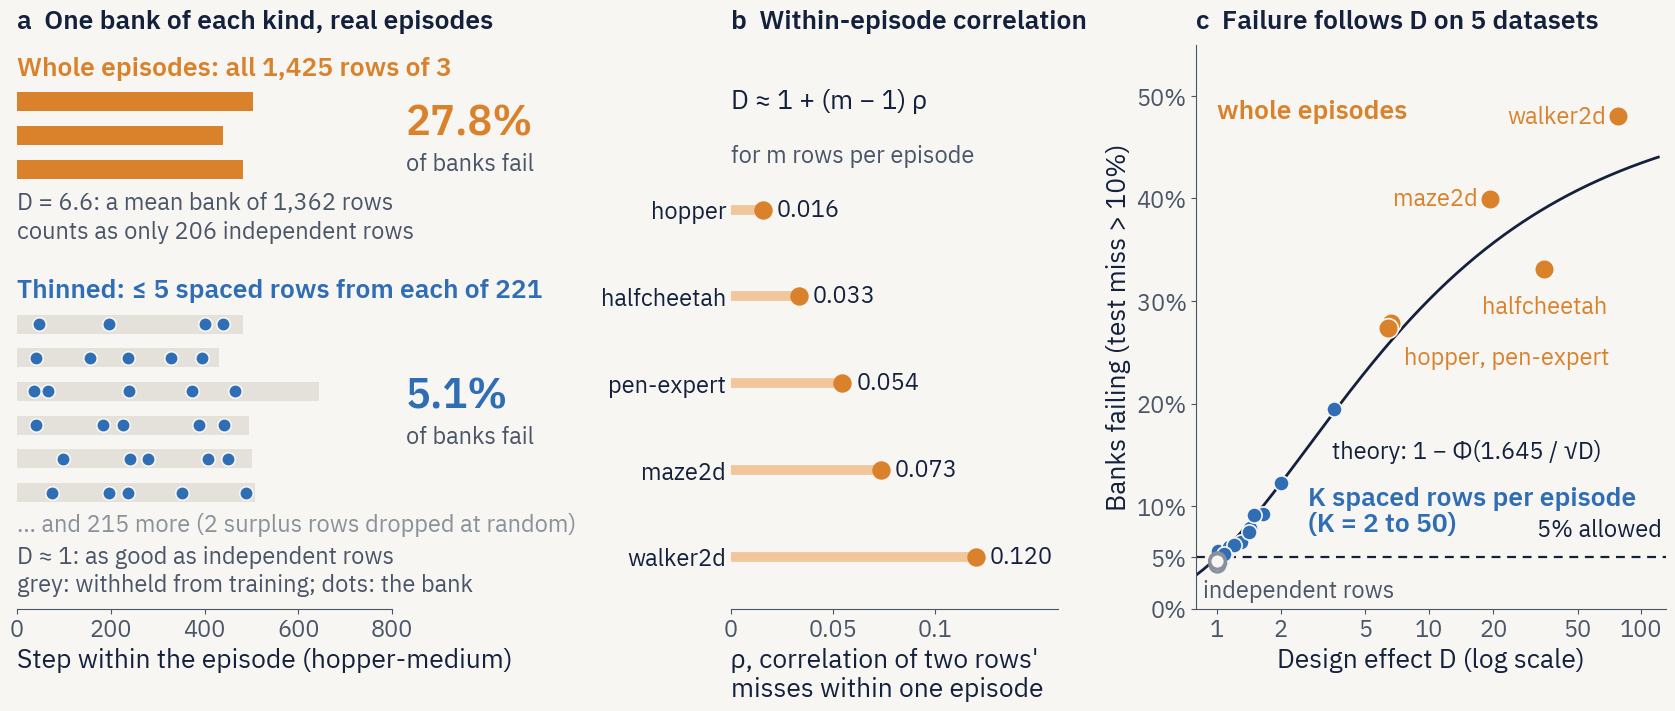

saved runs\wbcp_viz\bank_dependence.png


what,value,source
pool episodes (hopper-medium-v2 held-out half) and their length range,"1094 episodes, 153-872 steps",runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000/frozen.npz (episode)
"whole-episode bank drawn (seed 911, calibration/reference.py:83-86 rule, n = 1,103)","3 episodes of lengths 503, 439, 483; 1425 rows",runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000/frozen.npz (episode) + calibration/reference.py:83-86
"thinned bank drawn (calibration/bank.py stratified_bank, K = 5, n = 1,103, seed 911)","221 episodes, 1103 rows; first 6 episode lengths 483, 431, 645, 495, 501, 507; rows kept in those 6: 4, 5, 5, 5, 5, 5",runs/wbcp_frozen/hopper-medium-v2-s202609171-u100000/frozen.npz (episode) + calibration/bank.py:45-102
thinned bank drawn: surplus rows removed by the trim (K x episodes - n),2 (5 x 221 - 1103),calibration/bank.py:96-101 (computed on the draw)
"whole-episode banks, hopper n = 1,103: failure (uniform BQ-CP, normalized, no shift)","27.8% [26.4%, 29.2%] of 4000 banks",runs/wbcp_dependence/hopper-u100000/e1_blocks.json; DEPENDENCE.md Change 3
"whole-episode banks, hopper: Monte Carlo design effect D and mean bank size","D = 6.603, mean bank 1361.6 rows",runs/wbcp_dependence/hopper-u100000-reservation/predictions_k5/predictions.json
whole-episode bank effective size n / D,1361.6 / 6.603 = 206.2 rows,runs/wbcp_dependence/hopper-u100000-reservation/predictions_k5/predictions.json (computed)
"BCA's thinned bank (stratified_bank K = 5, n = 1,103): failure","5.1% [4.4%, 5.8%] of 4000 banks",runs/wbcp_dependence/hopper-u100000-reservation/r1_resv_k5.json; DEPENDENCE.md Change 9
"BCA's thinned bank: Monte Carlo design effect D (finite 1,094-episode pool; shown as D ≈ 1)",0.994,runs/wbcp_dependence/hopper-u100000-reservation/predictions_k5/predictions.json
"rho (ICC of the miss indicator), hopper-medium-v2",0.0155 (shown 0.016),"runs/wbcp_dependence/hopper-u100000/predictions.json; DEPENDENCE.md Changes 2, 10, 12"


In [5]:
draw("bank_dependence")

## 5. Critic alignment: which error the band certifies

### What this shows

TD3+BC has two critic heads, but its actor follows only the first one. The actor loss is

$$\mathcal L_\pi = -\lambda\,\overline{Q_1\big(s,\pi(s)\big)} + \overline{d(s,a)\,\big(\pi(s)-a\big)^2},\qquad \lambda = \frac{\alpha_{\text{TD3+BC}}}{\operatorname{mean}|Q_1(s,\pi(s))|}$$

(`algorithms/td3_bc.py:128-139`; `[..., 0]` at line 130 selects $Q_1$). Here $d(s,a)$ is BCA's per-row dose on the behaviour-cloning term, and $d \equiv 1$ is plain TD3+BC. In the recorded baseline, BCA's code calibrates the residual of the *minimum* of the two online heads, both in the scale fit and in the refresh (`algorithms/td3_bc_bca.py:173`, `:255`). The current code still does this:

$$s_{\min} = \frac{|t - \min(Q_1,Q_2)|}{\sigma(s,a)} \quad\text{rather than}\quad s_1 = \frac{|t - Q_1|}{\sigma(s,a)},$$

where $t = r + \gamma(1-d_{\text{done}})\min(Q_1',Q_2')(s',\tilde a')$ is TD3's target from the Polyak target heads (`td3_bc_bca.py:146-156`). Because $\min(Q_1,Q_2)\le Q_1$,

$$t - Q_1 = \big(t - \min(Q_1,Q_2)\big) - \big(Q_1 - \min(Q_1,Q_2)\big).$$

On rows where $Q_1 > Q_2$, $Q_1$'s residual is shifted by the head gap, and $s_{\min}$ never sees that shift. WBCP gives a threshold $\hat\lambda$ such that, with credibility $\beta = 0.95$, at most $\alpha = 0.1$ of the score it was calibrated on lies above it. That guarantee holds only for the calibrated score. A bank **fails** for $Q_1$ when its min-calibrated threshold, applied under the min band's own $\sigma$, misses more than 10% of $Q_1$'s residuals in the population:

$$\Pr_{\text{pop}}\!\Big(\tfrac{|t-Q_1|}{\sigma_{\min}} > \hat\lambda_{\min}\Big) > \alpha .$$

A valid rule fails in at most $1-\beta = 5\%$ of banks.

**Panel a (Illustration)** is computed exactly from the closed forms of the linear-quadratic harness (`experiments/signal/lq_harness.py`), re-implemented in numpy. The system, $K^*$ and the direction $D$ are read from `runs/wbcp_signal/lq/results.json`, and $K^*$ is checked against the recorded value. The panel uses the harness's `q1_optimistic` case: $Q_1 = Q^\pi + \kappa\,\|a-\beta(s)\|^2$ and $Q_2 = Q^\pi$, so $\min(Q_1,Q_2) = Q^\pi$ exactly. The settings are poor behaviour data ($K_b = 0$, so $\beta(s)=0$), $\kappa = 1$ and π offset 1, all cells of the step-3 grid. The state $s=(0.5,0.5,0.5)$ was chosen for display. "True Q" means $Q^\pi$, the value of the policy being evaluated.

**Panel b (real data)** comes from signal-study step 2. It uses the five frozen TD3+BC critics that converged. Each pool has 4,000 banks of 1,024 independent held-out rows at logged actions, calibrated with uniform-weight WBCP at α = 0.1, β = 0.95 and BCA's deployed threshold $\max(\hat\lambda,\lambda_{\text{HPD}})$. σ is refit separately for each signal.

### How to read it

- **a.** The orange curve is the true $Q^\pi$. Here it also equals $Q_2$ and $\min(Q_1,Q_2)$. The dashed blue curve is $Q_1$.
  - Inside the grey band of logged actions ($\beta(s)\pm 2\sigma_b$, $\sigma_b = 0.2$), the two curves almost agree.
  - Away from the data, $Q_1$ rises above the truth (blue shading). The actor's Q term pulls toward $Q_1$'s peak, 1.25 from $\beta(s)$. The true $Q^\pi$ peaks at 0.63 on this slice.
  - At $Q_1$'s peak, $Q_1$ is wrong by 1.57. Because $\min(Q_1,Q_2)=Q_2$ everywhere, none of $Q_1$'s error, there or anywhere else, appears in $t-\min(Q_1,Q_2)$.
  - The panel does **not** claim that a band calibrated on $Q_1$ would cover the error at the peak. Banks see only logged actions (see Takeaway, Limits).
- **b.** Each pool has two bars, each with its 95% interval:
  - orange: the share of banks whose min-calibrated threshold misses more than 10% of $Q_1$'s residuals;
  - blue: the same share for a threshold calibrated on $Q_1$.
  - The dashed line is the 5% budget. Pools are sorted by the orange bar.
  - The note "Q1 > Q2 on 46–54% of rows" is a warning. The real heads are **not** one-sidedly optimistic as in panel a. They disagree in both directions, by about one residual (median $|Q_1-Q_2|$ ÷ median $|r_{\min}|$ = 0.52–1.15). That disagreement alone is enough to move $Q_1$'s residual outside the min band.

### Takeaway

- **The min-calibrated band fails for $Q_1$ on all five converged D4RL pools.** Between 10.5% (pen-expert) and 82.4% (walker2d) of banks fail, against a 5% budget.
- **Calibrating $Q_1$ restores validity at little cost.** 4.0–5.1% of banks fail, and the band is 2–10% wider. In the same files, the $Q_1$ band still covers the min residual: 0.0–2.9% of banks fail.
- **A small shift in mean miscoverage produces many failures.** Under the min band, $Q_1$'s mean miscoverage is 8.9–10.9%, against 8.5% for the min's own residual. My reading, not separately tested: WBCP's threshold sits about 1.5 points inside the 10% target, and this shift uses up most of that slack.
- **Decision (a judgment, not yet implemented).** SIGNAL_STUDY.md adopted $Q_1$ as the measurement signal **for step 4** under decision rule 1, whose precondition was only partly met. CRITIC_ALIGNMENT.md recommends calibrating $Q_1$ on TD3+BC. BCA's TD3+BC code still calibrates the min (`td3_bc_bca.py:173`, `:255`).
- **What it does not show.** Switching the signal changes what the band certifies, but barely changes the dose the actor receives: the signals' mean doses differ by at most 0.006. Whether calibrating $Q_1$ improves the actor is untested. The step-4 placement study is still running and has no outcomes yet.
- **Limits.**
  - The banks use logged actions and independent rows, not BCA's thinned per-episode banks.
  - The earlier alignment study (online σ, 1,000 banks) found 8.2–70.2% against 4.2–5.9%, with the same conclusion. Its run folder is not on disk, so those numbers are cited from the write-up only.
  - pen-cloned and pen-human are excluded because their critics did not converge.

### Sources

- `experiments/wbcp/CRITIC_ALIGNMENT.md`
- `experiments/signal/SIGNAL_STUDY.md` (steps 2–3, decision rules)
- `runs/wbcp_signal/frozen/<pool>/evaluation_b4000_s2026100201.json` (design `iid`; fields `signals.{min,q1}.failure.{q1,min}`, `half_width_mean`, `head_disagreement`; pools hopper-medium-v2, walker2d, halfcheetah, maze2d, pen-expert)
- `runs/wbcp_signal/lq/results.json` (meta: system, `k_opt`, `direction`, settings)
- `experiments/signal/lq_harness.py:175-195, 227-231, 267-292, 516-517, 582, 657`
- `algorithms/td3_bc.py:128-139`
- `algorithms/td3_bc_bca.py:146-156, 173, 255`
- Figure module: `experiments/wbcp/viz/fig_critic_alignment.py`

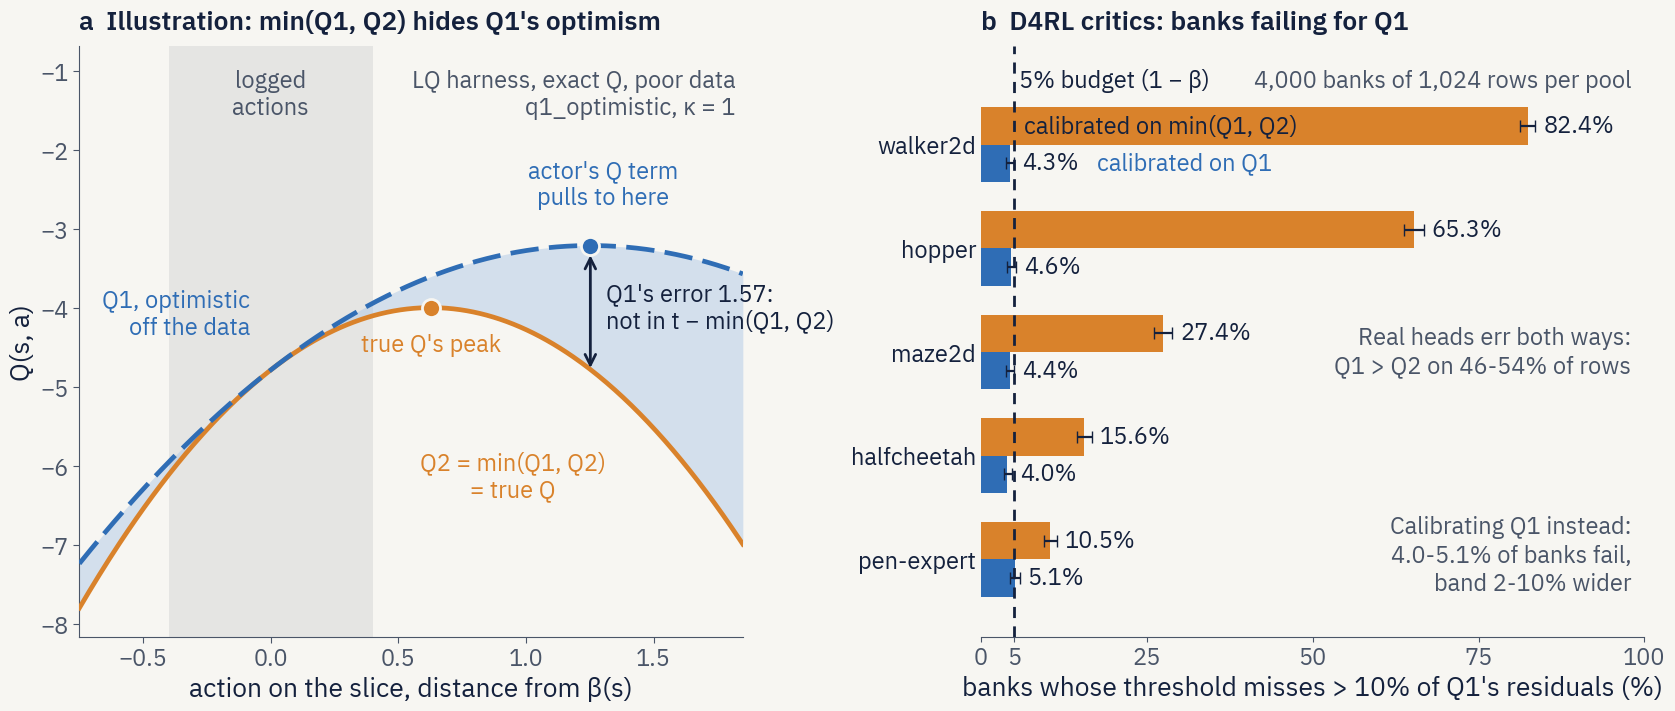

saved runs\wbcp_viz\critic_alignment.png


what,value,source
"panel a setting: LQ harness case, behaviour, pi_offset, kappa, state","q1_optimistic, poor, 1, 1, s = (0.5, 0.5, 0.5)","cells of the step-3 grid (runs/wbcp_signal/lq/results.json meta: kappas, pi_offsets, behaviors); state chosen for display"
"panel a heads: Q1 = Q^pi + kappa ||a - beta(s)||^2, Q2 = Q^pi, so min(Q1, Q2) = Q^pi",construction,"experiments/signal/lq_harness.py:267-292 (case_critic, head_error)"
"panel a logged-action span along the slice, beta(s) +/- 2 sigma_b",+/-0.4,"behavior_noise 0.2, runs/wbcp_signal/lq/results.json meta.settings"
panel a peak of true Q on the slice (distance from beta(s)),0.63,"computed in fig_critic_alignment.lq_slice from runs/wbcp_signal/lq/results.json meta (system, k_opt, direction, settings) with lq_harness.py's closed forms"
panel a peak of Q1 (Q1's global maximiser; distance from beta(s)),1.25,"computed in fig_critic_alignment.lq_slice from runs/wbcp_signal/lq/results.json meta (system, k_opt, direction, settings) with lq_harness.py's closed forms"
"panel a Q1's error at its peak, Q1 - Q^pi",1.57,"computed in fig_critic_alignment.lq_slice from runs/wbcp_signal/lq/results.json meta (system, k_opt, direction, settings) with lq_harness.py's closed forms"
"panel a axis ranges: Q(s, a) and the slice coordinate",Q -7.80 to -3.21; slice -0.75 to 1.85,"computed in fig_critic_alignment.lq_slice from runs/wbcp_signal/lq/results.json meta (system, k_opt, direction, settings) with lq_harness.py's closed forms"
"panel b walker2d (walker2d-medium-replay-v2): banks failing for Q1's residual, min(Q1, Q2)-calibrated band, with 95% interval","82.4% [81.2, 83.6]",runs/wbcp_signal/frozen/walker2d/evaluation_b4000_s2026100201.json designs[iid].signals.min.failure.q1
"panel b walker2d: banks failing for Q1's residual, Q1-calibrated band, with 95% interval","4.3% [3.7, 5.0]",runs/wbcp_signal/frozen/walker2d/evaluation_b4000_s2026100201.json designs[iid].signals.q1.failure.q1
"panel b walker2d: mean half-width, Q1 band / min band",1.102,"runs/wbcp_signal/frozen/walker2d/evaluation_b4000_s2026100201.json designs[iid].signals.{q1,min}.half_width_mean"


In [6]:
draw("critic_alignment")

## 6. From calibrated width to BC dose, and why mean dose is not strength

### What this shows

WBCP certifies one threshold $R$ on the normalized score $|r|/\sigma(s,a)$. Here $\sigma(s,a) = u\,\eta(s,a)$ is the fitted scale and $u$ is the residual unit. BCA deploys $R = \max(\hat\lambda, \lambda_{\text{hpd}})$ with uniform weights, at $\alpha = 0.1$ and $\beta = 0.95$. It turns the certified band into a width per row, then into a multiplier on the host's behaviour-cloning (BC) term, called the **dose** (`calibration/dose.py`, `frozen_level_dose` and `level_critic_dose`):

$$U(s,a) = R\,u\,\max(\eta(s,a),10^{-6}), \qquad m(s,a) = 1 + b\,\frac{U(s,a)}{U(s,a)+u} = 1 + b\,\frac{R\,\eta(s,a)}{1+R\,\eta(s,a)}, \qquad b = 0.5 .$$

The unit $u$ cancels, so the dose depends only on the dimensionless width $U/u = R\,\eta$. The blend $b = 0.5$ is set in `configs/td3_bc.yaml`, and the CQL and ReBRAC configs use the same value. So $m$ runs from 1 at zero width toward a cap of 1.5, which no finite width reaches.

In TD3+BC the dose multiplies each transition's BC term, at the recorded action $a$ (`algorithms/td3_bc.py` l.127-138):

$$\mathcal{L}_\pi = -\lambda\,\mathbb{E}\big[Q_1(s,\pi(s))\big] + \mathbb{E}\Big[\,\mathrm{sg}(m(s,a))\,\tfrac{1}{d_A}\|\pi(s)-a\|^2\Big], \qquad \lambda = \frac{\alpha_{\text{TD3+BC}}}{\mathbb{E}|Q_1|},\ \ \alpha_{\text{TD3+BC}} = 2.5 .$$

$\alpha_{\text{TD3+BC}}$ is TD3+BC's own weight. It is not the calibration miscoverage $\alpha = 0.1$.

The same map multiplies ReBRAC's actor BC term (its critic BC term is unchanged) and CQL's conservative gap. IQL does not use this map: it shrinks the capped advantage weight instead (ALGORITHMS.md, Procedure D).

**Panel a: real data.** Each of the five healthy TD3+BC pools has a frozen critic (signal study, step 2). For every scored row of the pool, the dose was computed from the Q1 signal's fitted $\eta$ and unit. The threshold is the pool's mean deployed WBCP threshold over 4,000 independent-row banks of 1,024 rows. The computation is a float32 NumPy port of `dose.py`. The module checks it against the run's own dose statistics: it reproduces the exact statistics at $\lambda^*$ to $10^{-6}$, and the bank-averaged statistics to $2\times10^{-4}$.

**Panel b: post hoc, not pre-registered.** In the step-3 linear-quadratic (LQ) harness, the true value $J$ and every gradient are exact. Step 3 compared each dose against a *constant dose with the same mean*. The panel shows the BC term's actual gradient norm at the starting actor, relative to that constant dose, for the Q1 signal.
- Orange is the oracle dose, built from the true Q1 error. Blue is BCA's dose.
- Each bar spans every replicate of every $\kappa$/offset cell of the case: 15 values for independent errors and 45 for the others. The markers are medians.

Matching the mean weight did not match strength. The write-up's reading (not separately tested) is this: rows with a large true error or a wide band tend to have large per-row gradient leverage (large $\|s\|$ or $\|\pi(s)-a\|$). Weighting them up enlarges the BC gradient even at the same mean weight.

### How to read it

**Panel a, curve**
- The x-axis is the width in residual units. The y-axis is the dose.
- The dashed line is the cap at 1.5.
- The dotted line is dose 1, the host's own BC weight.

**Panel a, shading**
- The vertical band is the range of $U/u$ that contains each pool's middle 90% of rows: 0.49 to 2.66, the union of the per-pool 5th to 95th percentiles.
- The horizontal band carries that range across to the doses those rows receive, 1.16 to 1.36.

**Panel a, strip on the right**
- There is one violin per pool, showing the per-row doses between the 0.5th and 99.5th percentiles. The black tick is the pool mean.
- Pool means are 1.26 to 1.33 and row SDs are 0.02 to 0.05. So the doses fill only a small slice of $[1, 1.5)$.

**Panel b, rows**
- Each row is one LQ error case with good or poor behaviour data.
- The dashed line at 1× is the constant dose with the same mean.
- The orange bars sit far to the right only in *independent errors*. There the oracle's BC gradient is 2.3 to 3.1× the constant dose's with good data, and 1.1 to 2.8× with poor data.
- The right-hand column is the oracle's change in true $J$ against the constant dose, averaged over the case's cells (Q1 signal). The only large means are in independent errors, the one case with a large strength ratio: +0.14 with good data and −1.01 with poor. Elsewhere the means stay between −0.041 and +0.008.
- BCA's bars stay within 1.00 to 1.03× in every row.

### Takeaway

On real pools, BCA's dose is close to uniform extra BC: about 1.3× the host's BC weight, with a row-to-row SD of 0.02 to 0.05. The map is bounded below 1.5, and most rows sit at $R\,\eta \approx 0.5$ to $2.7$, past the curve's steep start. That leaves little room for rows to differ. The write-up suggests the cap is why targeting is weak, but that is untested.

Post hoc, most of the oracle dose's apparent "targeting" advantage in step 3 is **strength**. In independent errors, at the same mean dose, its BC gradient was 2 to 3× the constant dose's, and its large effects on $J$ appear only there.

BCA's own small departures from the constant dose also follow its slightly higher strength. A strength-only model correlates 0.85 with them over all 216 step-3 cells (three signals).

So a control matched on mean dose does not isolate targeting, and step 4 is designed to match **realized strength** instead. The step-4 placement study is still running and has no results yet. Nothing in this figure comes from it.

### Sources

- `calibration/dose.py` l.53-60 (`level_critic_dose`) and l.74-76 (`frozen_level_dose`): the dose map
- `algorithms/td3_bc.py` l.127-138 and `algorithms/td3_bc_bca.py` l.285-300: where the dose enters TD3+BC
- `algorithms/rebrac.py` l.229-235: actor BC only
- `configs/td3_bc.yaml` l.20, `configs/cql.yaml` l.38, `configs/rebrac.yaml` l.21: blend $b = 0.5$
- `ALGORITHMS.md`: "What BCA changes" (l.41-48) and Procedure D (l.320-357)
- `runs/wbcp_signal/frozen/<pool>/heads.npz` and `evaluation_b4000_s2026100201.json`, for hopper-medium-v2, walker2d, halfcheetah, maze2d and pen-expert
- `runs/wbcp_signal/strength_reanalysis.json` and `experiments/signal/strength_reanalysis.py`
- `runs/wbcp_signal/lq/results.json`
- `experiments/signal/SIGNAL_STUDY.md`: step 2 table (l.217-223), oracle against constant (l.312-318), and "Post hoc: same mean, different strength" (l.392-417)
- Figure code: `experiments/wbcp/viz/fig_bc_dose.py`

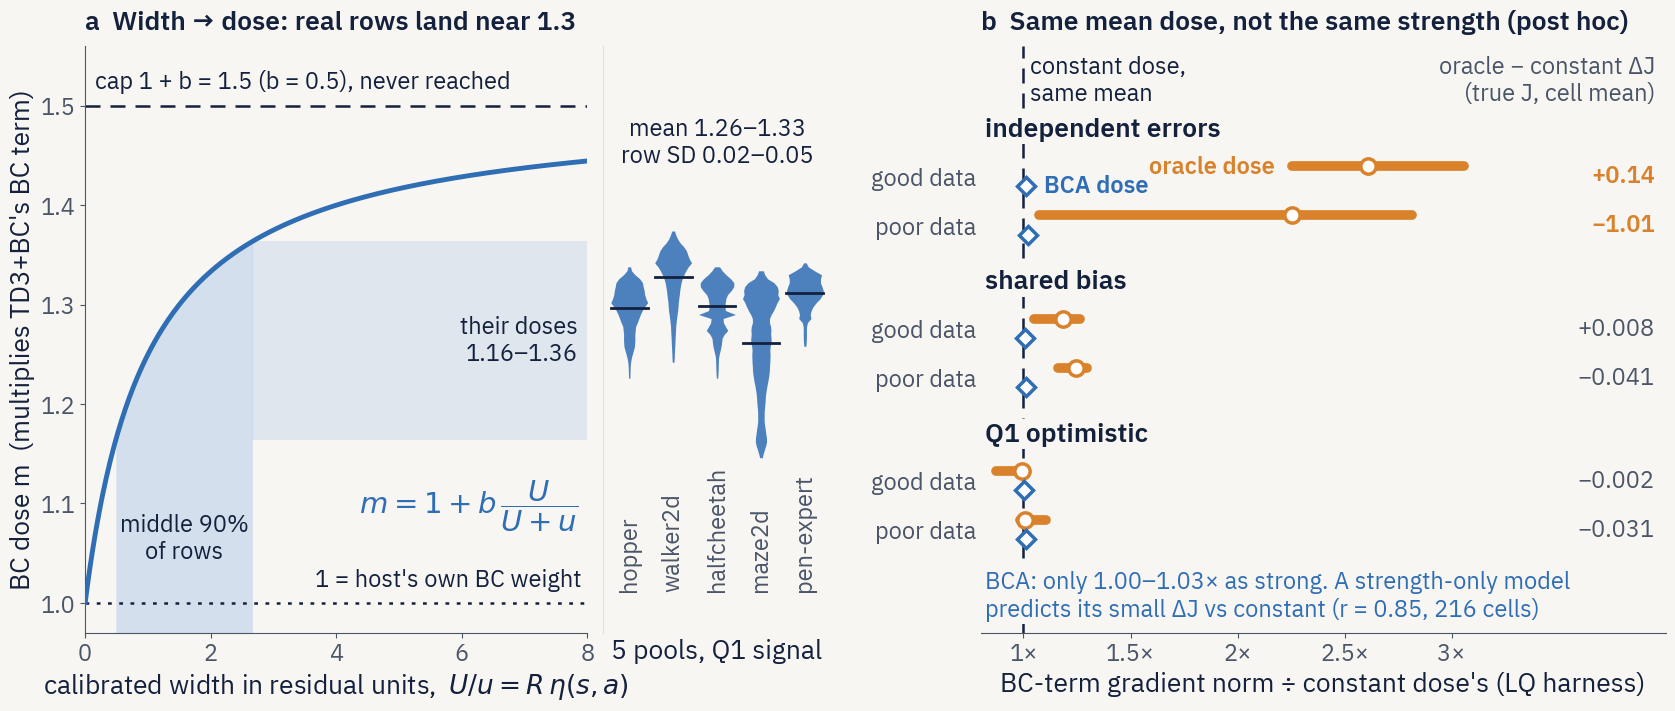

saved runs\wbcp_viz\bc_dose.png


what,value,source
blend b (BC dose cap is 1 + b),0.5 (cap 1.5),"configs/td3_bc.yaml l.20 (also configs/cql.yaml l.38, configs/rebrac.yaml l.21); ALGORITHMS.md l.337, l.352"
dose map,"m = 1 + b*U/(U+u), U = R*u*max(eta,1e-6)","calibration/dose.py l.53-60 (level_critic_dose), l.75-76 (frozen_level_dose); ALGORITHMS.md l.337"
U/u range holding the middle 90% of rows of every pool (union of per-pool 5th-95th percentiles),0.49 to 2.66 (dose 1.164 to 1.363),computed from runs/wbcp_signal/frozen//heads.npz eta_q1 at the mean iid-bank threshold
"hopper: mean deployed WBCP threshold R over 4,000 iid banks (Q1 signal)",1.1983,runs/wbcp_signal/frozen/hopper-medium-v2/evaluation_b4000_s2026100201.json designs[iid].signals.q1.threshold_mean
"hopper: per-row BC dose at that threshold, mean / SD (500,285 rows)",1.2964 / 0.0237 (step-2 bank average: 1.2963 / 0.0237),computed with the dose.py port from heads.npz; check: runs/wbcp_signal/frozen/hopper-medium-v2/evaluation_b4000_s2026100201.json doses.q1.banks.iid; experiments/signal/SIGNAL_STUDY.md l.219-223
"walker2d: mean deployed WBCP threshold R over 4,000 iid banks (Q1 signal)",1.5671,runs/wbcp_signal/frozen/walker2d/evaluation_b4000_s2026100201.json designs[iid].signals.q1.threshold_mean
"walker2d: per-row BC dose at that threshold, mean / SD (151,195 rows)",1.3274 / 0.0295 (step-2 bank average: 1.3273 / 0.0295),computed with the dose.py port from heads.npz; check: runs/wbcp_signal/frozen/walker2d/evaluation_b4000_s2026100201.json doses.q1.banks.iid; experiments/signal/SIGNAL_STUDY.md l.219-223
"halfcheetah: mean deployed WBCP threshold R over 4,000 iid banks (Q1 signal)",1.2090,runs/wbcp_signal/frozen/halfcheetah/evaluation_b4000_s2026100201.json designs[iid].signals.q1.threshold_mean
"halfcheetah: per-row BC dose at that threshold, mean / SD (999,000 rows)",1.2981 / 0.0254 (step-2 bank average: 1.2980 / 0.0254),computed with the dose.py port from heads.npz; check: runs/wbcp_signal/frozen/halfcheetah/evaluation_b4000_s2026100201.json doses.q1.banks.iid; experiments/signal/SIGNAL_STUDY.md l.219-223
"maze2d: mean deployed WBCP threshold R over 4,000 iid banks (Q1 signal)",1.2407,runs/wbcp_signal/frozen/maze2d/evaluation_b4000_s2026100201.json designs[iid].signals.q1.threshold_mean


In [7]:
draw("bc_dose")

## Provenance

- Code: `experiments/wbcp/viz/` (one module per figure, plus `style.py`). Each module's docstring says which data it
  reads. Every module was reviewed against the repo code and its sources, and each figure re-rendered after the fixes.
- Data: recorded runs under `runs/` (frozen score pools in `runs/wbcp_frozen`, benchmark results in `runs/wbcp_bench`,
  `runs/wbcp_dependence` and `runs/wbcp_hosts`, the signal study in `runs/wbcp_signal`). Nothing here trains a model
  or runs a benchmark; every figure renders in seconds.
- Write-ups behind the numbers: `experiments/wbcp/DEPENDENCE.md`, `experiments/wbcp/CRITIC_ALIGNMENT.md`,
  `experiments/signal/SIGNAL_STUDY.md`, `ALGORITHMS.md`, `INTEGRATION.md`.